In [2]:
!pip install pyathena pandas matplotlib seaborn plotly

In [3]:
import os
from pyathena import connect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
conn = connect(
    s3_staging_dir = 's3://binance-data-lucas-2026/queries/',
    region_name = 'sa-east-1',
    aws_access_key_id = os.getenv("AWS_ACCESS_KEY"),
    aws_secret_access_key = os.getenv("AWS_SECRET_KEY"),
)

In [5]:
query = """
SELECT
    symbol,
    trade_time_readable as time,
    price
FROM "crypto_datalake"."datalake"
ORDER BY time ASC
LIMIT 1000
"""

In [6]:
df = pd.read_sql(query, conn)

/tmp/ipykernel_85/1168034203.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [7]:
df.count()

symbol    792
time      792
price     792
dtype: int64

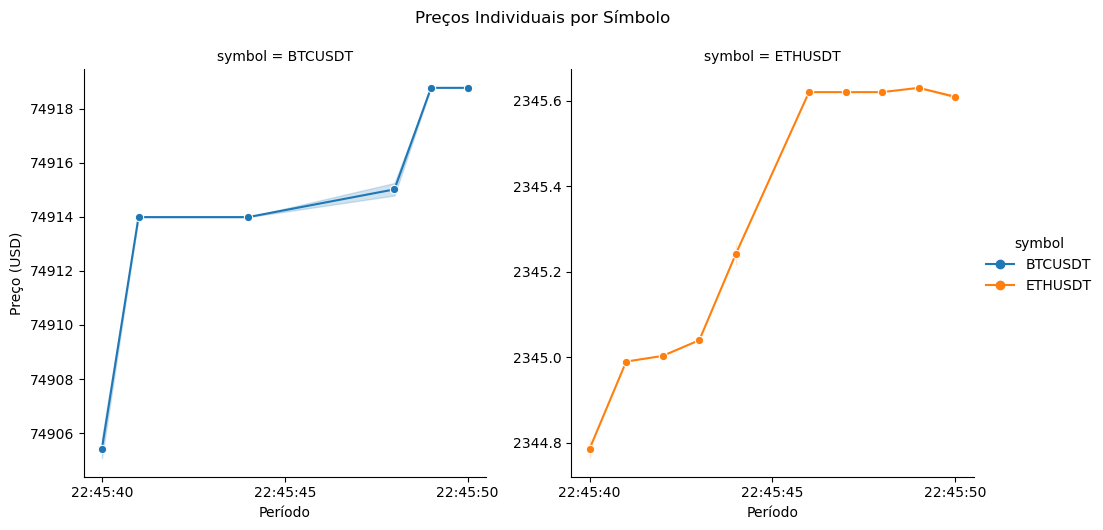

In [8]:
g = sns.relplot(
    data = df,
    x = 'time',
    y = 'price',
    hue = 'symbol',
    col = 'symbol',
    kind = 'line',
    col_wrap = 2,
    marker = 'o',
    facet_kws = {'sharey': False}
)

g.fig.suptitle('Preços Individuais por Símbolo', y = 1.05)
g.set_axis_labels('Período', 'Preço (USD)')

plt.show()

In [9]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook_connected"

fig = px.line(
    df,
    x="time",
    y="price",
    color="symbol",
    facet_col='symbol',
    facet_col_spacing=0.05,
    markers=True,
    title='Análise de Preços por Ativo',
    labels={'time': 'Período', 'price': 'Preço (USD)'}
)

fig.update_yaxes(matches=None, showticklabels=True)
fig.update_layout(height=500, title_x=0.5)
fig.show()

In [10]:
df.head()

,symbol,time,price
0,BTCUSDT,2026-04-16 22:45:40,74903.36
1,BTCUSDT,2026-04-16 22:45:40,74903.36
2,ETHUSDT,2026-04-16 22:45:40,2344.71
3,BTCUSDT,2026-04-16 22:45:40,74903.82
4,ETHUSDT,2026-04-16 22:45:40,2344.90
